## 0. Setup


In [1]:
import os, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

DATA_ROOT = Path('/kaggle/input/datasets/qasimmaajid/isolated')
OUT  = Path('/kaggle/working')
MODEL_OUT = OUT / 'models'
LOG_OUT   = OUT / 'logs'
MODEL_OUT.mkdir(parents=True, exist_ok=True)
LOG_OUT.mkdir(parents=True, exist_ok=True)

print('TF version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))
print('Data root exists:', DATA_ROOT.exists())
if DATA_ROOT.exists():
    print('Files:', sorted(p.name for p in DATA_ROOT.iterdir()))

2026-05-01 15:47:08.416822: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777650428.817914      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777650428.936566      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777650429.923823      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777650429.923871      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777650429.923874      57 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Data root exists: True
Files: ['isolated_signs_processed.pkl']


## 1. Load the processed sequences


In [2]:
DROPPED_SIGNS = {
    'go', 'grandma', 'grandpa', 'mom', 'dad',
    'sleep', 'sleepy', 'thankyou', 'happy', 'look',
}

df = pd.read_pickle(DATA_ROOT / 'isolated_signs_processed.pkl')
print(f'Before filter: {len(df)} sequences, {df["sign"].nunique()} signs')

if DROPPED_SIGNS:
    df = df[~df['sign'].isin(DROPPED_SIGNS)].reset_index(drop=True)
    print(f'After filter:  {len(df)} sequences, {df["sign"].nunique()} signs')

sample_feat = df['features'].iloc[0]
INPUT_DIM = sample_feat.shape[1]
print(f'Feature dim per frame: {INPUT_DIM}')
assert INPUT_DIM == 85

print('\nPer-sign counts:')
print(df['sign'].value_counts().to_string())
print('\nFrame length stats:')
print(df['n_frames'].describe())


Before filter: 9976 sequences, 30 signs
After filter:  6709 sequences, 20 signs
Feature dim per frame: 85

Per-sign counts:
sign
listen     391
drink      375
sad        371
food       370
bye        369
home       368
water      362
finish     351
see        348
please     348
cat        342
yes        338
hello      329
brother    326
dog        319
hungry     295
wait       283
no         278
have       276
now        270

Frame length stats:
count    6709.000000
mean       26.963482
std        28.101852
min         5.000000
25%        11.000000
50%        17.000000
75%        30.000000
max       231.000000
Name: n_frames, dtype: float64


## 2. Pad/truncate every sequence to 30 frames


In [3]:
TARGET_LEN = 30

def pad_or_truncate(frames: np.ndarray, target_len: int = TARGET_LEN) -> np.ndarray:
    n = len(frames)
    if n >= target_len:
        start = (n - target_len) // 2
        return frames[start:start + target_len]
    padded = np.zeros((target_len, frames.shape[1]), dtype=np.float32)
    padded[:n] = frames
    return padded

X_seq = np.stack([pad_or_truncate(s) for s in df['features']])  # (N, 30, 63)
print('Sequence tensor shape:', X_seq.shape, 'dtype:', X_seq.dtype)

Sequence tensor shape: (6709, 30, 85) dtype: float32


## 3. Encode string labels to integers


In [4]:
labels_sorted = sorted(df['sign'].unique())
label_to_idx = {lab: i for i, lab in enumerate(labels_sorted)}
idx_to_label = {i: lab for lab, i in label_to_idx.items()}

y = np.array([label_to_idx[s] for s in df['sign']], dtype=np.int64)
print(f'NUM_CLASSES = {len(labels_sorted)}')
print('Classes:', labels_sorted)

with open(MODEL_OUT / 'phrases_label_encoder.pkl', 'wb') as f:
    pickle.dump({'label_to_idx': label_to_idx, 'idx_to_label': idx_to_label}, f)

NUM_CLASSES = 20
Classes: ['brother', 'bye', 'cat', 'dog', 'drink', 'finish', 'food', 'have', 'hello', 'home', 'hungry', 'listen', 'no', 'now', 'please', 'sad', 'see', 'wait', 'water', 'yes']


## 4. Stratified train/val/test split (80/10/10)


In [5]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(X_seq))
train_idx, temp_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
val_idx,   test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=y[temp_idx])

X_train, y_train = X_seq[train_idx], y[train_idx]
X_val,   y_val   = X_seq[val_idx],   y[val_idx]
X_test,  y_test  = X_seq[test_idx],  y[test_idx]

print(f'train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}')

train: (5367, 30, 85), val: (671, 30, 85), test: (671, 30, 85)


## 5. Class weights


In [6]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print('Class weights (highest 5):')
for cls, w in sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f'  {idx_to_label[cls]:10s} weight={w:.3f}')

Class weights (highest 5):
  now        weight=1.242
  have       weight=1.214
  no         weight=1.203
  wait       weight=1.187
  hungry     weight=1.137


## 6. Sequence-aware augmentation


In [7]:
def augment_sequence(features, label):
    # features: (30, 85) — only augment hand shape (first 63 features)
    hand_shape = features[:, :63]
    body_ctx   = features[:, 63:]

    seq = tf.reshape(hand_shape, (TARGET_LEN, 21, 3))
    angle = tf.random.uniform([], -0.26, 0.26)
    cos_a, sin_a = tf.cos(angle), tf.sin(angle)
    x = seq[..., 0] * cos_a - seq[..., 1] * sin_a
    y_ = seq[..., 0] * sin_a + seq[..., 1] * cos_a
    seq = tf.stack([x, y_, seq[..., 2]], axis=-1)
    scale = tf.random.uniform([], 0.9, 1.1)
    seq *= scale
    shift = tf.random.uniform([3], -0.05, 0.05)
    seq += shift
    seq += tf.random.normal(tf.shape(seq), stddev=0.005)
    hand_shape = tf.reshape(seq, (TARGET_LEN, 63))

    # Light noise on body context
    body_ctx = body_ctx + tf.random.normal(tf.shape(body_ctx), stddev=0.01)

    return tf.concat([hand_shape, body_ctx], axis=1), label


BATCH = 128
train_ds = (tf.data.Dataset.from_tensor_slices((X_train.astype(np.float32), y_train))
            .map(augment_sequence, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(4096).batch(BATCH).prefetch(tf.data.AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val.astype(np.float32), y_val))
            .batch(BATCH).prefetch(tf.data.AUTOTUNE))
print('train_ds element_spec:', train_ds.element_spec)

I0000 00:00:1777650575.398700      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777650575.404517      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


train_ds element_spec: (TensorSpec(shape=(None, 30, 85), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))


## 7. Model — stacked LSTM


In [8]:
NUM_CLASSES = len(labels_sorted)

model = keras.Sequential([
    keras.layers.Input(shape=(TARGET_LEN, 85)),
    keras.layers.Masking(mask_value=0.0),
    keras.layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.0),
    keras.layers.LSTM(64, dropout=0.2, recurrent_dropout=0.0),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(NUM_CLASSES, activation='softmax'),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3'),
             keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5')],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 30, 85)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 128)        │       109,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,876 (663.58 KB)

 Trainable params: 169,876 (663.58 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train


In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4,
                                       min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(str(MODEL_OUT / 'phrases_model.h5'),
                                     monitor='val_accuracy', save_best_only=True),
    keras.callbacks.CSVLogger(str(LOG_OUT / 'phrases_training.csv')),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/100


I0000 00:00:1777650616.562703     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


42/42 - 7s - 155ms/step - accuracy: 0.1299 - loss: 2.7344 - top3: 0.3400 - top5: 0.4887 - val_accuracy: 0.2921 - val_loss: 2.3092 - val_top3: 0.5365 - val_top5: 0.6900 - learning_rate: 1.0000e-03
Epoch 2/100


42/42 - 1s - 21ms/step - accuracy: 0.2554 - loss: 2.2012 - top3: 0.5657 - top5: 0.7378 - val_accuracy: 0.3845 - val_loss: 1.9178 - val_top3: 0.7198 - val_top5: 0.8212 - learning_rate: 1.0000e-03
Epoch 3/100


42/42 - 1s - 21ms/step - accuracy: 0.3304 - loss: 1.9439 - top3: 0.6635 - top5: 0.8137 - val_accuracy: 0.4933 - val_loss: 1.6792 - val_top3: 0.7571 - val_top5: 0.8718 - learning_rate: 1.0000e-03
Epoch 4/100


...

42/42 - 1s - 21ms/step - accuracy: 0.7781 - loss: 0.7383 - top3: 0.9253 - top5: 0.9618 - val_accuracy: 0.7943 - val_loss: 0.7432 - val_top3: 0.9344 - val_top5: 0.9598 - learning_rate: 1.0000e-03
Epoch 43/100


42/42 - 1s - 21ms/step - accuracy: 0.7621 - loss: 0.7406 - top3: 0.9266 - top5: 0.9637 - val_accuracy: 0.7973 - val_loss: 0.7251 - val_top3: 0.9329 - val_top5: 0.9583 - learning_rate: 1.0000e-03
Epoch 44/100
42/42 - 1s - 21ms/step - accuracy: 0.7706 - loss: 0.7374 - top3: 0.9279 - top5: 0.9637 - val_accuracy: 0.7899 - val_loss: 0.7388 - val_top3: 0.9359 - val_top5: 0.9642 - learning_rate: 1.0000e-03
Epoch 45/100
42/42 - 1s - 20ms/step - accuracy: 0.7751 - loss: 0.7350 - top3: 0.9281 - top5: 0.9627 - val_accuracy: 0.7884 - val_loss: 0.7385 - val_top3: 0.9314 - val_top5: 0.9642 - learning_rate: 1.0000e-03
Epoch 46/100
42/42 - 1s - 20ms/step - accuracy: 0.7850 - loss: 0.7015 - top3: 0.9344 - top5: 0.9635 - val_accuracy: 0.7750 - val_loss: 0.7479 - val_top3: 0.9210 - val_top5: 0.9583 - learning_rate: 1.0000e-03
Epoch 47/100

Epoch 47: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
42/42 - 1s - 21ms/step - accuracy: 0.7861 - loss: 0.7114 - top3: 0.9247 - top5: 0.9627 - v

42/42 - 1s - 20ms/step - accuracy: 0.8070 - loss: 0.6284 - top3: 0.9411 - top5: 0.9702 - val_accuracy: 0.7988 - val_loss: 0.6987 - val_top3: 0.9404 - val_top5: 0.9627 - learning_rate: 5.0000e-04
Epoch 55/100
42/42 - 1s - 19ms/step - accuracy: 0.8049 - loss: 0.6381 - top3: 0.9380 - top5: 0.9655 - val_accuracy: 0.7884 - val_loss: 0.7215 - val_top3: 0.9300 - val_top5: 0.9598 - learning_rate: 5.0000e-04
Epoch 56/100
42/42 - 1s - 20ms/step - accuracy: 0.8161 - loss: 0.6021 - top3: 0.9434 - top5: 0.9715 - val_accuracy: 0.7869 - val_loss: 0.7078 - val_top3: 0.9255 - val_top5: 0.9627 - learning_rate: 5.0000e-04
Epoch 57/100


42/42 - 1s - 20ms/step - accuracy: 0.8077 - loss: 0.6182 - top3: 0.9437 - top5: 0.9711 - val_accuracy: 0.8003 - val_loss: 0.6817 - val_top3: 0.9389 - val_top5: 0.9627 - learning_rate: 5.0000e-04
Epoch 58/100
42/42 - 1s - 19ms/step - accuracy: 0.8187 - loss: 0.5885 - top3: 0.9452 - top5: 0.9726 - val_accuracy: 0.7943 - val_loss: 0.7063 - val_top3: 0.9359 - val_top5: 0.9627 - learning_rate: 5.0000e-04
Epoch 59/100
42/42 - 1s - 20ms/step - accuracy: 0.8077 - loss: 0.6196 - top3: 0.9428 - top5: 0.9717 - val_accuracy: 0.7943 - val_loss: 0.7074 - val_top3: 0.9389 - val_top5: 0.9613 - learning_rate: 5.0000e-04
Epoch 60/100
42/42 - 1s - 20ms/step - accuracy: 0.8215 - loss: 0.5787 - top3: 0.9463 - top5: 0.9730 - val_accuracy: 0.7988 - val_loss: 0.6981 - val_top3: 0.9344 - val_top5: 0.9613 - learning_rate: 5.0000e-04
Epoch 61/100


42/42 - 1s - 21ms/step - accuracy: 0.8252 - loss: 0.5931 - top3: 0.9415 - top5: 0.9706 - val_accuracy: 0.8092 - val_loss: 0.6775 - val_top3: 0.9374 - val_top5: 0.9657 - learning_rate: 5.0000e-04
Epoch 62/100
42/42 - 1s - 20ms/step - accuracy: 0.8148 - loss: 0.6157 - top3: 0.9402 - top5: 0.9687 - val_accuracy: 0.7973 - val_loss: 0.6983 - val_top3: 0.9389 - val_top5: 0.9642 - learning_rate: 5.0000e-04
Epoch 63/100
42/42 - 1s - 20ms/step - accuracy: 0.8129 - loss: 0.6210 - top3: 0.9400 - top5: 0.9694 - val_accuracy: 0.7973 - val_loss: 0.7187 - val_top3: 0.9344 - val_top5: 0.9613 - learning_rate: 5.0000e-04
Epoch 64/100
42/42 - 1s - 20ms/step - accuracy: 0.8126 - loss: 0.6024 - top3: 0.9463 - top5: 0.9735 - val_accuracy: 0.7988 - val_loss: 0.6889 - val_top3: 0.9329 - val_top5: 0.9657 - learning_rate: 5.0000e-04
Epoch 65/100

Epoch 65: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
42/42 - 1s - 21ms/step - accuracy: 0.8195 - loss: 0.5859 - top3: 0.9463 - top5: 0.9711 - v

## 9. Training curves


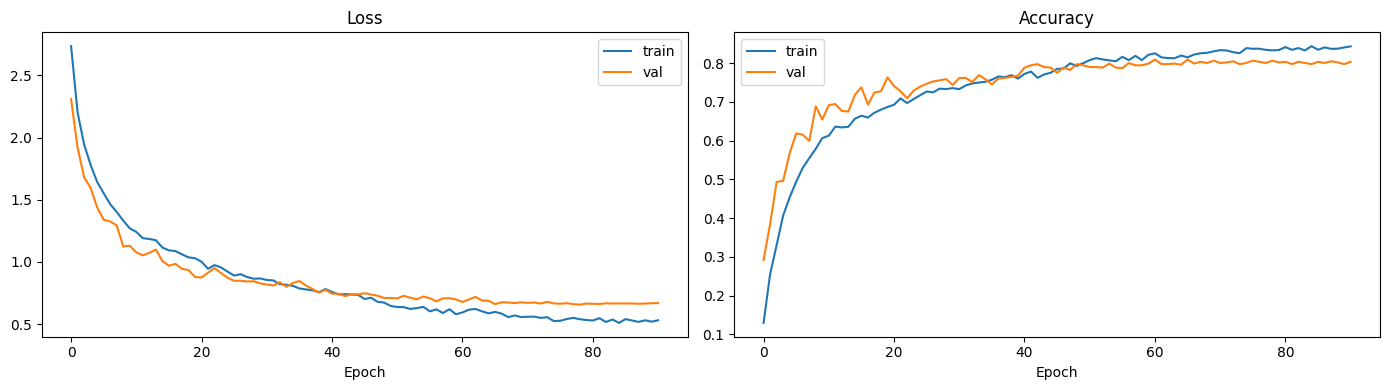

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig(LOG_OUT / 'phrases_training_curves.png', dpi=150)
plt.show()

## 10. Evaluate on the held-out test set


In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred_proba = model.predict(X_test.astype(np.float32), batch_size=BATCH, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

test_acc = accuracy_score(y_test, y_pred)
top3 = np.mean([y_test[i] in np.argsort(y_pred_proba[i])[-3:] for i in range(len(y_test))])
top5 = np.mean([y_test[i] in np.argsort(y_pred_proba[i])[-5:] for i in range(len(y_test))])

print(f'Top-1 accuracy: {test_acc:.4f}')
print(f'Top-3 accuracy: {top3:.4f}')
print(f'Top-5 accuracy: {top5:.4f}')

label_names = [idx_to_label[i] for i in sorted(idx_to_label)]
report = classification_report(y_test, y_pred, target_names=label_names,
                                output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df.to_csv(LOG_OUT / 'phrases_classification_report.csv')
print('\nPer-class report:')
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

Top-1 accuracy: 0.8316
Top-3 accuracy: 0.9463
Top-5 accuracy: 0.9672

Per-class report:
              precision    recall  f1-score   support

     brother       0.96      0.72      0.82        32
         bye       0.75      0.89      0.81        37
         cat       0.87      0.79      0.83        34
         dog       0.63      0.69      0.66        32
       drink       0.71      0.78      0.74        37
      finish       0.88      0.86      0.87        35
        food       0.72      0.92      0.81        37
        have       0.91      0.75      0.82        28
       hello       0.88      0.85      0.86        33
        home       0.87      0.92      0.89        37
      hungry       0.78      0.93      0.85        30
      listen       0.94      0.87      0.91        39
          no       0.78      0.75      0.76        28
         now       0.74      0.85      0.79        27
      please       0.94      0.83      0.88        35
         sad       0.91      0.78      0.84    

## 11. Confusion matrix


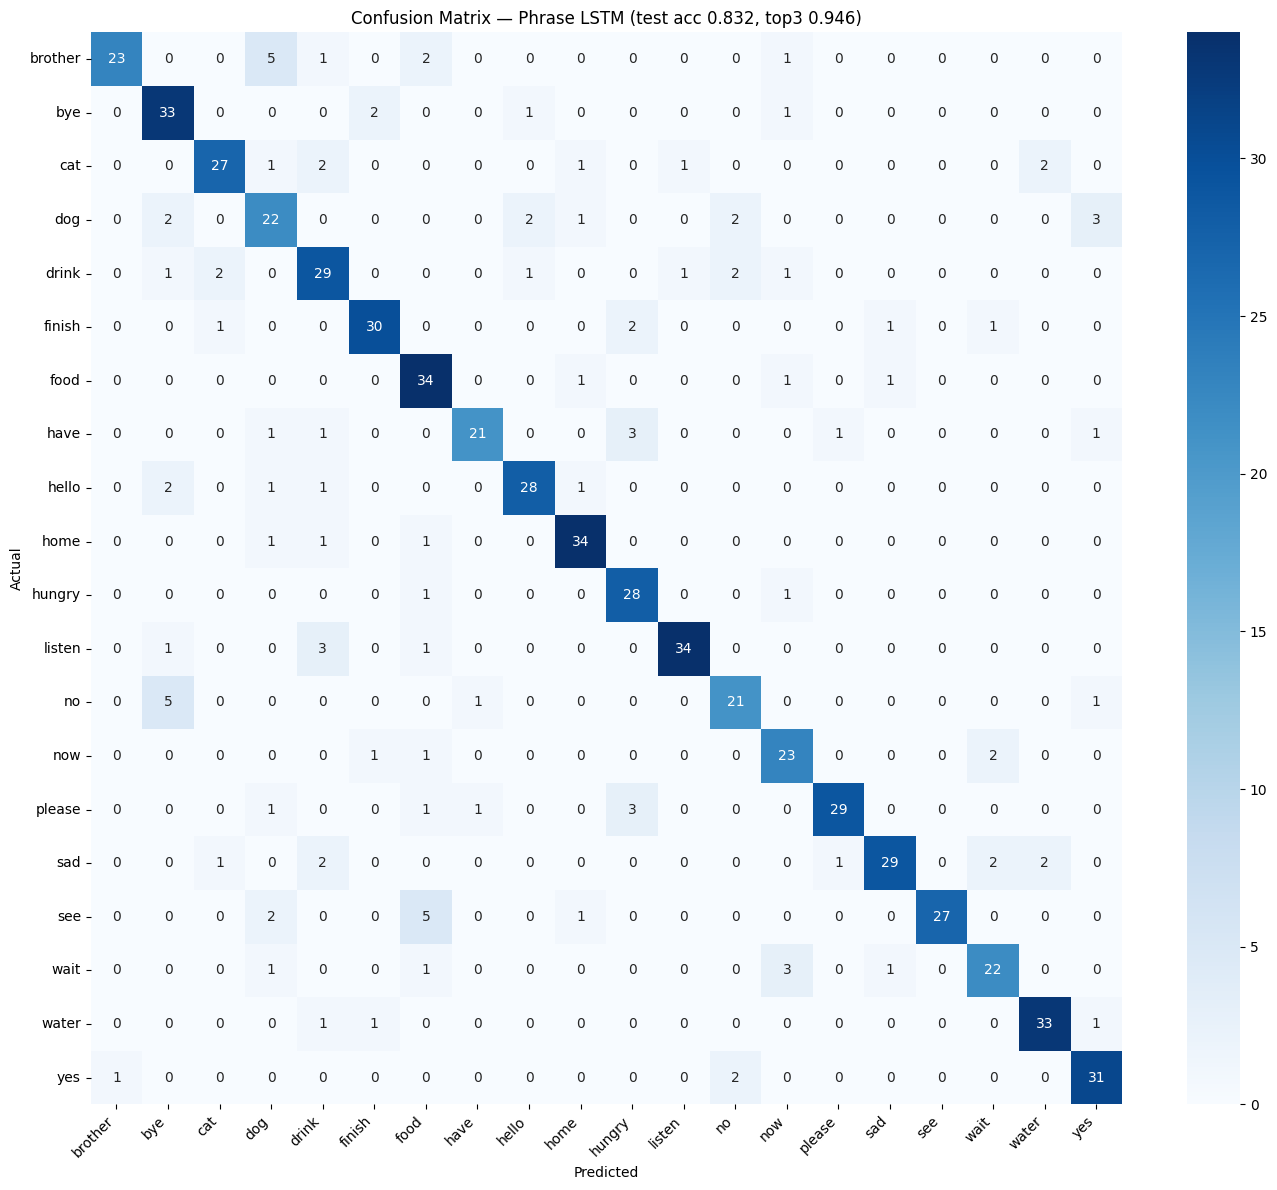

In [12]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names,
            cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — Phrase LSTM (test acc {test_acc:.3f}, top3 {top3:.3f})')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(LOG_OUT / 'phrases_confusion_matrix.png', dpi=150)
plt.show()

## 12. Weak signs and confused pairs

In [13]:
weak = [(lab, report[lab]['f1-score']) for lab in label_names if report[lab]['f1-score'] < 0.80]
weak.sort(key=lambda x: x[1])
print('Weak signs (F1 < 0.80):')
for lab, f1 in weak:
    print(f'  {lab:10s} F1={f1:.3f}')
if not weak:
    print('  (none)')

print('\nMost-confused pairs (>10% misclassified):')
for i, true_lab in enumerate(label_names):
    total = cm[i].sum()
    if total == 0: continue
    for j, pred_lab in enumerate(label_names):
        if i != j and cm[i][j] > 0.10 * total:
            pct = 100 * cm[i][j] / total
            print(f'  {true_lab} → {pred_lab}: {cm[i][j]} ({pct:.1f}%)')

Weak signs (F1 < 0.80):
  dog        F1=0.657
  drink      F1=0.744
  no         F1=0.764
  now        F1=0.793

Most-confused pairs (>10% misclassified):
  brother → dog: 5 (15.6%)
  have → hungry: 3 (10.7%)
  no → bye: 5 (17.9%)
  see → food: 5 (14.3%)
  wait → now: 3 (10.7%)


## 13. Convert to TFLite


In [15]:
# Rebuild model with non-cuDNN LSTM kernel for TFLite conversion.
# recurrent_dropout > 0 disables cuDNN — at inference time it's a no-op,
# so predictions are identical to the trained model.
inference_model = keras.Sequential([
    keras.layers.Input(shape=(TARGET_LEN, INPUT_DIM)),
    keras.layers.Masking(mask_value=0.0),
    keras.layers.LSTM(128, return_sequences=True, recurrent_dropout=1e-5),
    keras.layers.LSTM(64, recurrent_dropout=1e-5),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(NUM_CLASSES, activation='softmax'),
])
inference_model.set_weights(model.get_weights())

# Sanity check: predictions should match within float tolerance
sample = X_test[:5].astype(np.float32)
diff = np.abs(model.predict(sample, verbose=0) - inference_model.predict(sample, verbose=0)).max()
print(f'Max prediction diff between trained and inference model: {diff:.6f}')
assert diff < 1e-4, 'Inference model predictions differ from trained model'

converter = tf.lite.TFLiteConverter.from_keras_model(inference_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter._experimental_lower_tensor_list_ops = False
tflite_bytes = converter.convert()

tflite_path = MODEL_OUT / 'phrases_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_bytes)
print(f'Saved {tflite_path}, {tflite_path.stat().st_size/1e6:.2f} MB')

# Parity check on TFLite
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.resize_tensor_input(0, [1, TARGET_LEN, INPUT_DIM])
interpreter.allocate_tensors()
in_det  = interpreter.get_input_details()[0]
out_det = interpreter.get_output_details()[0]

n_match = 0
for i in range(20):
    s = X_test[i:i+1].astype(np.float32)
    interpreter.set_tensor(in_det['index'], s)
    interpreter.invoke()
    tflite_pred = np.argmax(interpreter.get_tensor(out_det['index']))
    keras_pred  = np.argmax(inference_model.predict(s, verbose=0))
    n_match += int(tflite_pred == keras_pred)
print(f'TFLite/Keras agreement on 20 test samples: {n_match}/20')


Max prediction diff between trained and inference model: 0.000000
INFO:tensorflow:Assets written to: /tmp/tmpf3vsxh6d/assets


INFO:tensorflow:Assets written to: /tmp/tmpf3vsxh6d/assets


Saved artifact at '/tmp/tmpf3vsxh6d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 85), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  132295202640272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132295202643728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132295202644112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132295202639504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132295202640656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132295200617872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132295200612496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132295200616336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132295202650832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132295202649488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132295202648528:

W0000 00:00:1777651026.561954      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777651026.561984      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saved /kaggle/working/models/phrases_model.tflite, 0.25 MB


INFO: Created TensorFlow Lite delegate for select TF ops.
I0000 00:00:1777651027.163077      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777651027.164586      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
INFO: TfLiteFlexDelegate delegate: 4 nodes delegated out of 100 nodes with 3 partitions.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


TFLite/Keras agreement on 20 test samples: 20/20
